### Understanding the Dataset

In [251]:
import pandas as pd

df = pd.read_csv("Bank Customer Churn Prediction.csv")

In [252]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [253]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [254]:
# Summary statistics using .describe()
df.describe(include="all")

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1.569094e+07,650.528800,NaN,NaN,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,NaN,NaN,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,NaN,NaN,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,NaN,NaN,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000


In [255]:
# Checking if missing data or null values are present in the dataset
df.isnull().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [256]:
df.duplicated().sum()

np.int64(0)

### Overall churn rate

In [257]:
churn = df['churn'].mean()*100
print("Overall Churn Rate :", round(churn, 2), "%")

Overall Churn Rate : 20.37 %


### Creating business-ready features

In [258]:
# 1. Age Groups (Young, Middle, Senior)

df['age_group'] = pd.cut(df['age'], bins=[17,30,50,100], labels=['Young','Middle_Aged','Senior'])

In [259]:
df["age_group"].value_counts()

age_group
Middle_Aged    6771
Young          1968
Senior         1261
Name: count, dtype: int64

In [260]:
# 2. Tenure Groups
#Tenure = How long customer stayed with bank

df['tenure_group'] = pd.cut(df['tenure'], bins=[-1,3,7,10], labels=['New', 'Mid_Term', 'Loyal'])

#Meaning:
#0–3 years - New
#4–7 years - Mid-Term
#8–10 years - Loyal

In [261]:
df['tenure_group'].value_counts()

tenure_group
Mid_Term    3996
New         3505
Loyal       2499
Name: count, dtype: int64

In [262]:
# 3. Credit Score Category

df['credit_score_category'] = pd.cut(df['credit_score'], bins=[300,580,670,740,850], labels=['Poor','Fair','Good','Excellent'])

#Poor - High Risk
#Excellent - Low Risk                                  

In [263]:
df['credit_score_category'].value_counts()

credit_score_category
Fair         3350
Good         2397
Poor         2393
Excellent    1860
Name: count, dtype: int64

In [264]:
# 5. Estimated Salary Range

df['salary_range'] = pd.qcut(df['estimated_salary'], q=3, labels=['Low_Income', 'Middle_Income', 'High_Income'])

In [265]:
df['salary_range'].value_counts()

salary_range
Middle_Income    3334
Low_Income       3333
High_Income      3333
Name: count, dtype: int64

### Using Matplotlib to show churn patterns visually

In [266]:
import matplotlib.pyplot as plt

#### Overall Churn Distribution

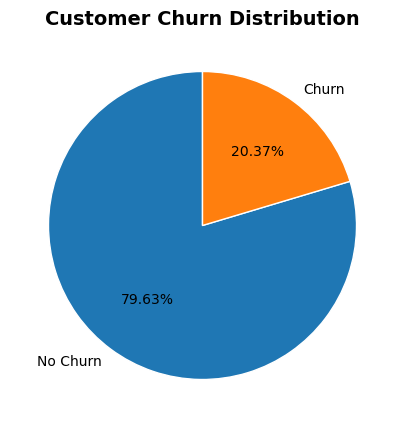

In [267]:
churn_counts = df['churn'].value_counts()

plt.figure(figsize=(7,5))
plt.pie(churn_counts, labels=['No Churn', 'Churn'], autopct='%.2f%%', startangle=90, wedgeprops={"edgecolor": "white"})
plt.title("Customer Churn Distribution", fontsize=14, fontweight='bold')
plt.show()

#### Churn Rate by Age Group

C:\Users\HP\AppData\Local\Temp\ipykernel_26532\2875559358.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_churn = df.groupby('age_group')['churn'].mean()*100


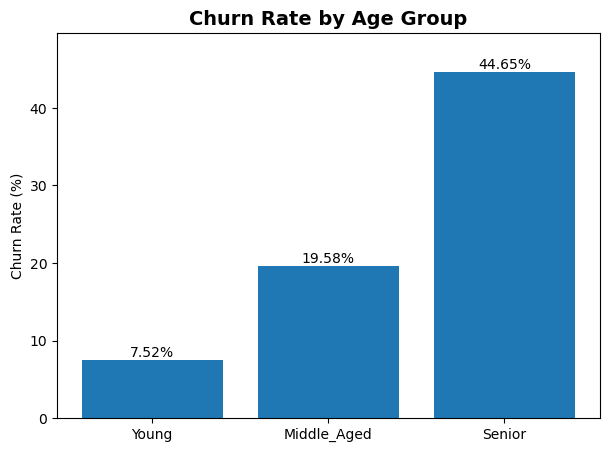

In [268]:
age_churn = df.groupby('age_group')['churn'].mean()*100

plt.figure(figsize=(7,5))
bars = plt.bar(age_churn.index, age_churn.values)
plt.title("Churn Rate by Age Group", fontsize=14, fontweight="bold")
plt.ylabel("Churn Rate (%)")

# Add data labels
for i in range(len(age_churn)):
    plt.text(i, age_churn.values[i], 
             f"{age_churn.values[i]:.2f}%", ha="center", va="bottom")
plt.ylim(0, age_churn.max() + 5)
plt.show()

#### Churn by Active Member

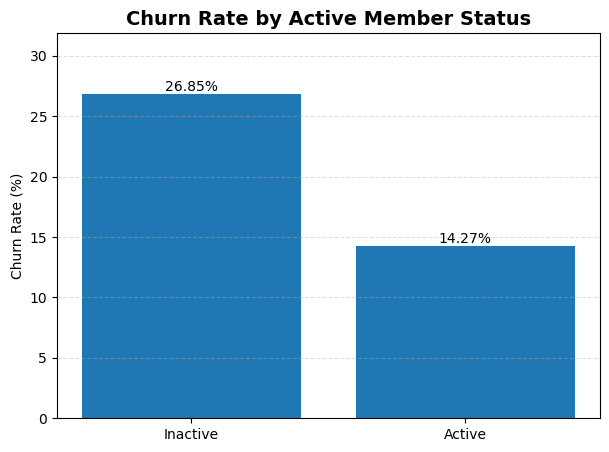

In [269]:
active_churn = df.groupby("active_member")["churn"].mean() * 100

plt.figure(figsize=(7,5))
bars = plt.bar(["Inactive", "Active"], active_churn.values)

plt.title("Churn Rate by Active Member Status", fontsize=14, fontweight="bold")
plt.ylabel("Churn Rate (%)")

for i in range(len(active_churn)):
    plt.text(i, active_churn.values[i],
             f"{active_churn.values[i]:.2f}%",
             ha="center", va="bottom")

plt.ylim(0, active_churn.max()+5)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

In [270]:
pip install psycopg2-binary sqlalchemy

Note: you may need to restart the kernel to use updated packages.


In [271]:
from sqlalchemy import create_engine

# Step 1: Connect to PostgreSQL
username = "postgres"      # default user
password = "abc123" # the password you set during installation
host = "localhost"         # if running locally
port = "5432"              # default PostgreSQL port
database = "bank_customer_churn_analysis"    # the database created in pgAdmin

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

# Step 2: Load DataFrame into PostgreSQL
table_name = "customer"
df.to_sql(table_name, engine, if_exists="replace", index=False)

print(f"Data successfully loaded into table '{table_name}' in database '{database}'.")

Data successfully loaded into table 'customer' in database 'bank_customer_churn_analysis'.
